## TODO 리스트를 활용한 에이전트 플래닝

복잡한 장기 작업 수행 시, 에이전트는 **TODO List**를 핵심 내비게이션 도구로 활용합니다. 이는 **Context Rot** 및 **Mission Drift**를 방지하고 목표를 일관성 있게 유지하는 데 필수적입니다.

*   **활용 사례**: [Claude Code Plan Mode](https://www.anthropic.com/engineering/claude-code-best-practices), [Manus](https://manus.im/blog/Context-Engineering-for-AI-Agents-Lessons-from-Building-Manus) 등
*   **구조**: `content`(작업 설명)와 `status`(pending, in_progress, completed)로 구성
*   **효과**: 툴 호출 증가에 따른 컨텍스트 손실 방지 및 작업 집중력 유지

> **Tip**: TODO 리스트의 지속적인 갱신(Recitation)은 에이전트의 장기 기억력을 보완합니다.

**참고 자료**
*   [Claude Code Plan Mode](https://www.anthropic.com/engineering/claude-code-best-practices)
*   [Context Rot 개념](https://research.trychroma.com/context-rot)
*   [Manus 컨텍스트 엔지니어링](https://manus.im/blog/Context-Engineering-for-AI-Agents-Lessons-from-Building-Manus)

## 도구 설계

### TODO 관리 툴

에이전트가 목표를 관리하기 위한 `write_todos` 및 `read_todos` 툴의 역할은 다음과 같습니다.

*   **`write_todos`**: 전체 TODO 리스트를 재작성하여 State 갱신 (작업 추가/수정/상태 변경)
*   **`read_todos`**: 현재 State의 TODO 리스트 조회
*   **운영 방식**: 개별 항목 수정이 아닌 리스트 전체 갱신을 통해 유연한 목표 관리 지원








In [1]:
# 프롬프트 출력 함수 show_prompt 사용 목적, LLM 프롬프트 예시 시각화
from util.messages_in_jupyter import show_prompt

from deep_agents_from_scratch.prompts import WRITE_TODOS_DESCRIPTION, WRITE_TODOS_DESCRIPTION_KOR

# WRITE_TODOS_DESCRIPTION 프롬프트 내용을 시각적으로 출력, LLM 툴 설명 확인 용도
show_prompt(WRITE_TODOS_DESCRIPTION_KOR)


╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  복잡한 워크플로의 진행 상황을 추적하기 위한 구조화된 작업 목록을 생성하고 관리합니다.                          │
│                                                                                                                 │
│  ## 사용 시기                                                                                                   │
│  - 조정이 필요한 다단계 또는 비단순(non-trivial) 작업                                                           │
│  - 사용자가 여러 작업을 제공하거나 명시적으로 할 일 목록(todo list)을 요청할 때                                 │
│  - 별도 지시가 없는 한 단일·단순 작업에는 사용을 피할 것                                                        │
│                                                                                                                 │
│  ## 구조                                                                                                        │
│  - content, status, id를 가진 여러 todo 객체를 포함하는 단일 목록 유지                                          │
│  - 명확하고 실행 가능한 content 설명 사용                                                                       │
│  - status는 pending, in_progress, completed 중 하나                                                             │
│                                                                                                                 │
│  ## 모범 사례                                                                                                   │
│  - 한 번에 in_progress 작업은 하나만                                                                            │
│  - 작업이 완전히 끝나면 즉시 completed로 표시                                                                   │
│  - 변경 시 항상 전체 업데이트된 목록 전송                                                                       │
│  - 목록 집중도를 위해 관련 없는 항목 제거(Prune)                                                                │
│                                                                                                                 │
│  ## 진행 상황 업데이트                                                                                          │
│  - 작업 상태 변경·내용 수정 시 TodoWrite를 다시 호출                                                            │
│  - 실시간 진행 반영, 완료를 일괄 처리하지 말 것                                                                 │
│  - 막혔으면 in_progress 유지하고 blocker를 설명하는 새 작업 추가                                                │
│                                                                                                                 │
│  ## 매개변수                                                                                                    │
│  - todos: content와 status 필드를 가진 TODO 항목 목록                                                           │
│                                                                                                                 │
│  ## 반환값                                                                                                      │
│  전체 목록을 디스크 JSON 파일에 저장하고, 새 할 일 목록으로 에이전트 상태를 업데이트함.                         │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Graph 구축

`create_agent`를 사용하여 TODO 리스트를 적극적으로 활용하는 에이전트를 구축합니다.

*   **설계 목표**: 작업 완료 시마다 TODO 리스트를 재확인(Recitation)하는 전략 적용
*   **기대 효과**: 장기 작업 시 목표 이탈 방지 및 일관성 유지


In [2]:
from deep_agents_from_scratch.prompts import TODO_USAGE_INSTRUCTIONS, TODO_USAGE_INSTRUCTIONS_KOR

# TODO 리스트 사용 지침 프롬프트 시각화, 에이전트 툴 활용 시 참고 목적
show_prompt(TODO_USAGE_INSTRUCTIONS_KOR)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  사용자 요청에 따라:                                                                                            │
│  1. 도구 설명에 따라 사용자 요청 시작 시 write_todos 도구를 사용하여 TODO를 생성하십시오.                       │
│  2. TODO를 완료한 후 read_todos를 사용하여 TODO를 읽고 계획을 상기하십시오.                                     │
│  3. 수행한 작업과 TODO에 대해 반성하십시오.                                                                     │
│  4. 작업을 completed로 표시하고 다음 TODO로 진행하십시오.                                                       │
│  5. 모든 TODO가 완료될 때까지 이 과정을 계속하십시오.                                                           │
│                                                                                                                 │
│  중요: 모든 사용자 요청에 대해 항상 TODO 연구 계획을 만들고 위 지침에 따라 연구를 수행하십시오.                 │
│  중요: 추적해야 할 TODO 수를 최소화하기 위해 연구 작업을 *단일 TODO*로 묶는 것을 목표로 하십시오.               │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## 실행 및 테스트

초기 `todos`가 없는 상태에서 사용자 요청을 처리하는 플로우를 검증합니다.

1.  **초기화**: 빈 TODO 리스트로 시작
2.  **플래닝**: 사용자 요청 분석 후 첫 TODO 리스트 생성
3.  **실행**: `web_search` 등 툴을 활용하여 작업 수행 및 TODO 상태 업데이트

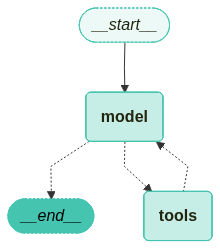

In [3]:
from deep_agents_from_scratch.deep_agent_todo_graph import DeepAgentTodoGraph


inputs = {
    "messages": [
        {
            "role": "user",
            "content": "Model Context Protocol (MCP) 에 대해서 짧고 간결하게 설명해 주세요.",
        }
    ]
}


workflow = DeepAgentTodoGraph(todos_file="todos.json")

workflow.show_graph()

In [4]:
from deep_agents_from_scratch.deep_agent_todo_graph import SYSTEM_PROMPT_KOR


show_prompt(SYSTEM_PROMPT_KOR)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  사용자 요청에 따라:                                                                                            │
│  1. 도구 설명에 따라 사용자 요청 시작 시 write_todos 도구를 사용하여 TODO를 생성하십시오.                       │
│  2. TODO를 완료한 후 read_todos를 사용하여 TODO를 읽고 계획을 상기하십시오.                                     │
│  3. 수행한 작업과 TODO에 대해 반성하십시오.                                                                     │
│  4. 작업을 completed로 표시하고 다음 TODO로 진행하십시오.                                                       │
│  5. 모든 TODO가 완료될 때까지 이 과정을 계속하십시오.                                                           │
│                                                                                                                 │
│  중요: 모든 사용자 요청에 대해 항상 TODO 연구 계획을 만들고 위 지침에 따라 연구를 수행하십시오.                 │
│  중요: 추적해야 할 TODO 수를 최소화하기 위해 연구 작업을 *단일 TODO*로 묶는 것을 목표로 하십시오.               │
│                                                                                                                 │
│                                                                                                                 │
│  ================================================================================                               │
│                                                                                                                 │
│  중요: web_search 도구를 한 번만 호출하고, 도구가 제공한 결과를 사용하여 사용자 질문에 답하십시오. 답변은       │
│  한국어로 작성하십시오.                                                                                         │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [6]:
from util.messages_in_jupyter import format_messages
# 실행
result = workflow.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Model Context Protocol (MCP) 에 대해서 짧고 간결하게 설명해 주세요.",
            }
        ],
        "todos": [],
    }
)

format_messages(result["messages"])


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  write_todos (call_qiuDoxu86ObXIkPsXYfQrxm3)
 Call ID: call_qiuDoxu86ObXIkPsXYfQrxm3
  Args:
    todos: [{'content': 'Model Context Protocol (MCP) 에 대해 짧고 간결하게 설명하기', 'status': 'pending'}]

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{'content': 'Model Context Protocol (MCP) 에 대해 짧고 간결하게 설명하기', 'status': 'pending'}
================================= Tool Message =================================
Name: write_todos

Updated todo list (1 items) and saved to todos.json

🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  read_todos (call_o3Farb7ZxhNa3KFbWe9jLcKP)
 Call ID: call_o3Farb7ZxhNa3KFbWe9jLcKP
  Args:

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{'content': 'Model Conte

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Model Context Protocol (MCP) 에 대해서 짧고 간결하게 설명해 주세요.                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Model Context Protocol (MCP) 에 대해 짧고 간결하게 설명하기",                                 │
│       "status": "pending"                                                                                       │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_qiuDoxu86ObXIkPsXYfQrxm3                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list (1 items) and saved to todos.json                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: read_todos                                                                                        │
│    Args: {}                                                                                                     │
│    ID: call_o3Farb7ZxhNa3KFbWe9jLcKP                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Model Context Protocol (MCP) 에 대해 짧고 간결하게 설명하기",                                 │
│       "status": "completed"                                                                                     │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_bdEwTFnq11GTLRSzpQQlulkO                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list (1 items) and saved to todos.json                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: read_todos                                                                                        │
│    Args: {}                                                                                                     │
│    ID: call_TvwT5EIItEsHupUphMrjZ4t6                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Current TODO List:                                                                                              │
│ 1. ✅ Model Context Protocol (MCP) 에 대해 짧고 간결하게 설명하기 (completed)                                   │
│                                                                                                                 │
│ (Source: todos.json)                                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 모델 컨텍스트 프로토콜(MCP)은 Anthropic이 개발한 개방형 표준 프로토콜로, AI 모델과 도구, 데이터베이스, 기타     │
│ 서비스와 같은 외부 시스템 간의 원활한 통합을 가능하게 합니다. 이는 표준화된 통신 계층 역할을 하여 AI 모델이     │
│ 다양한 출처의 데이터에 일관되고 효율적인 방식으로 접근하고 활용할 수 있도록 합니다. 본질적으로 MCP는 데이터     │
│ 교환을 위한 통합 언어를 제공함으로써 AI 어시스턴트를 외부 서비스에 연결하는 과정을 단순화합니다.                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

**실행 결과 추적 (LangSmith)**

아래 링크에서 에이전트의 실행 흐름과 State 변화를 상세히 확인할 수 있습니다.

*   [LangChain Smith Trace](https://smith.langchain.com/public/96c5c085-80d8-4b63-b5c9-f4b31b10fae3/r)